In [2]:
## Step 1: Install Required Libraries

!pip install yfinance scikit-learn matplotlib pandas

In [10]:
## Step 2: Import Libraries and Load the data

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## Step 3: Define X and Y
X = df[['Open']]
y = df['Close']

## Step 3.5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

## Step 4: Build and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept (α):", model.intercept_)
print("Slope (β):", model.coef_[0])


Train size: 99, Test size: 25
Intercept (α): -9.705231246690346
Slope (β): 1.0008685692803885


In [11]:
## Step 5: Make Predictions and Evaluate
y_pred = model.predict(X_test)

print("R-squared:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R-squared: 0.9544631215817694
MSE: 2216.4722193893895


In [12]:
print(y_pred)

[2910.78410881 3084.77488039 2998.27082063 3221.31307297 3165.3806443
 3193.17437505 3160.46578976 2412.39670641 2402.38802072 2977.30027549
 2996.20658664 2577.54002034 3094.60479939 2982.8917909  2909.70266799
 3127.04364876 2853.90276082 2862.58743774 2832.35711817 2617.57476311
 3116.23067432 3138.83977411 3109.5121565  3013.99894181 2958.55791263]


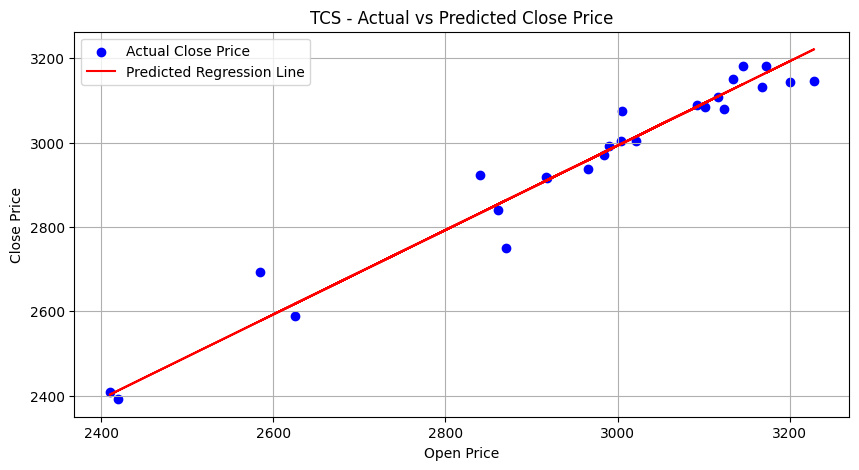

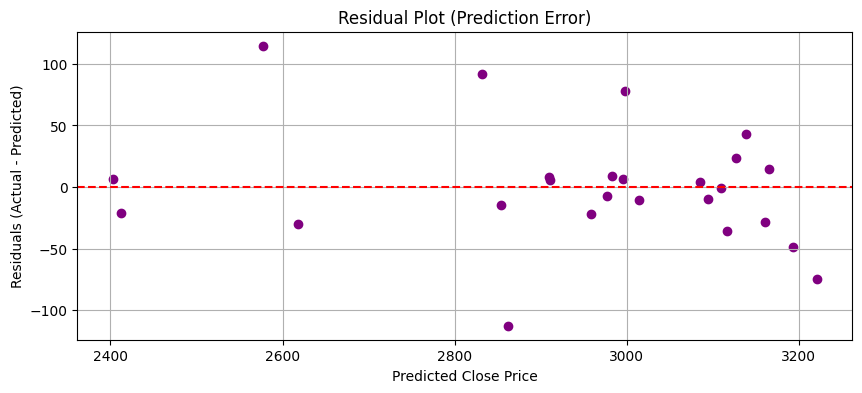

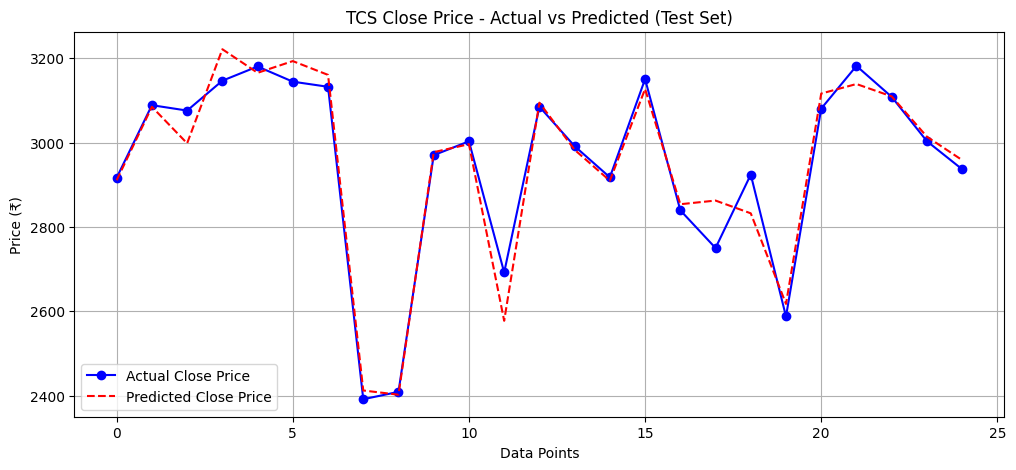

In [13]:
## Plot 1: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Close Price')
plt.plot(X_test, y_pred, color='red', label='Predicted Regression Line')
plt.title("TCS - Actual vs Predicted Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

## Plot 2: Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 4))
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot (Prediction Error)")
plt.xlabel("Predicted Close Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(True)
plt.show()

## Plot 3: Time Series - Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, color='blue', label='Actual Close Price', marker='o')
plt.plot(y_pred, color='red', label='Predicted Close Price', linestyle='--')
plt.title("TCS Close Price - Actual vs Predicted (Test Set)")
plt.xlabel("Data Points")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()